# STEP 1 — CORE PIPELINE (Prompt to Video Prompts)

## Useful Information

**LLM Chain**

User Input  
↓  
Prompt Template  
↓  
LLM  
↓  
Structured Output

The entire sequence is called an LLM chain because multiple processing steps are connected together to produce the final LLM output.

**Evaluation for the Generated Video**

**Scene alignment:** Does the prompt represent what the scene asks for?

**Visual detail:** Are subject, environment and appearance sufficiently described?

**Camera specificity:** Does it specify shot/angle/movement appropriately?

**Motion clarity:** Is it clear what should move and how?

**Style consistency:** Does it follow the requested visual style?

**Audio compliance:** Does it avoid requesting narration/dialogue (checking whether the video prompt accidentally tells Veo to generate people talking or a narrator speaking)?

## 1. Setup

### 1.1 Import

In [1]:
import os
from pprint import pprint
from typing import Optional

from dotenv import load_dotenv
from IPython.display import Image, display
from openai import OpenAI
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

### 1.2 Load Environment Variables

In [2]:
load_dotenv()

True

In [3]:
AI_MODEL_API_KEY = os.getenv("AI_MODEL_API_KEY")

if not AI_MODEL_API_KEY:
    raise ValueError("AI_MODEL_API_KEY not found in .env")

# OpenAI client used by the moderation nodes
moderation_client = OpenAI(api_key = AI_MODEL_API_KEY)


## 2. Video State and Data Models

In [4]:
# ---------------------------------------------------------------------------
# EnhancedPrompt (output schema for LLM)
# ---------------------------------------------------------------------------
class EnhancedPrompt(BaseModel):
    """Structured specification created from the user's original video request."""

    topic: str = Field(description = "The main topic or subject of the video")

    objective: str = Field(description = "What the video should communicate or achieve")

    audience: str = Field(description = "The intended audience for the video")

    tone: str = Field(description = "The desired communication tone")

    visual_style: str = Field(description = "The overall visual style of the video")

    duration_seconds: int = Field(description = "Target duration of the video in seconds")
    
    key_message: str = Field(description = "The main message the viewer should understand")

# ---------------------------------------------------------------------------------------------------------------------------------
# VideoScript (output schema for LLM): you pass the enhanced prompt to the LLM, and the LLM creates the VideoScript
# ---------------------------------------------------------------------------------------------------------------------------------
class VideoScript(BaseModel):
    """Structured narration script for the video."""

    title: str = Field(description = "A short title for the video")

    narration: str = Field(description = "The complete narration script for the video")

# ---------------------------------------------------------------------------
# Scene (output schema for LLM)
# ---------------------------------------------------------------------------
class Scene(BaseModel):
    """Represents one planned scene in the video."""

    scene_id: int = Field(description = "Sequential ID of the scene starting from 1")

    narration: str = Field(description = "The part of the narration spoken during this scene")

    visual_description: str = Field(description = "Description of what should visually happen during this scene")

    # Note: this planned duration is not sent to Veo, and every Veo clip is 8 s long.
    # In the final video (Step 5), the narration sets the length: the last frame is held if the scenes are shorter,
    # and the video is trimmed if they are longer (nothing is time-stretched).
    duration: float = Field(description = "Estimated duration of the scene in seconds")

    continues_previous_scene: bool = Field(description = "True if this scene should visually continue directly from the previous scene using the previous scene's final frame as its starting reference. False if this scene should begin as a new visual shot or setting. Scene 1 must always be False.")

# -------------------------------------------------------------------------------------------------------------------------------------------------
# Scene Plan (output schema for LLM): you pass the script + enhanced prompt to the LLM, and the LLM creates the scenes (including ScenePlan)
# -------------------------------------------------------------------------------------------------------------------------------------------------
class ScenePlan(BaseModel):

    scenes: list[Scene] = Field(description = "Ordered list of scenes for the video")

# --------------------------------------------------------------------------------------------------------
# Video Prompt (output schema for LLM): the instruction for the actual AI video-generation model for one scene.
# --------------------------------------------------------------------------------------------------------

class VideoPrompt(BaseModel):

    scene_id: int = Field(description = "ID of the corresponding scene")
    prompt: str = Field(description = "Detailed prompt for the video-generation model")

# -----------------------------------------------------------------------------------------------------------------------------------
# Video Prompt Plan (output schema for LLM): you pass list[Scene] to the LLM, and the LLM creates list[VideoPrompt]
# -----------------------------------------------------------------------------------------------------------------------------------

class VideoPromptPlan(BaseModel):
    """Structured collection of video-generation prompts."""

    video_prompts: list[VideoPrompt] = Field(description = "Ordered video-generation prompts for all scenes")


# ---------------------------------------------------------------------------
# LangGraph state
# ---------------------------------------------------------------------------

class VideoState(TypedDict, total = False): # total = False means not every key in the TypedDict is required to exist.
    """Shared state passed between nodes in the AgenticVideo LangGraph workflow."""

    # Safety

    is_safe: bool

    moderation_reason: Optional[str]

    # User input

    user_prompt: str                    # user's original request

    required_words: list[str]           # exact words or phrases that must appear

    reference_image: Optional[str]      # path to an uploaded image (provided by the user, to be used as the start of a video clip)

    enhanced_prompt: EnhancedPrompt     # more detailed version of the user's request
    
    review_action: str                  # "approve" or "edit" again after the user decides to edit the enhanced_prompt

    script: VideoScript                 # narration for the whole video

    scenes: list[Scene]                 # a list of multiple Scene objects
    
    video_prompts: list[VideoPrompt]    # a list of VideoPrompt objects

    initial_moderation_retry_count: int # counts how many times the user retries because their original input prompt failed moderation

    moderation_retry_count: int         # counts retries after the enhanced prompt has been reviewed/edited



### Example: EnhancedPrompt

- `EnhancedPrompt` is the structured output the LLM returns after enhancing the user's rough request.

- Each field in the model becomes one value in the result.

- An enhanced prompt might look like this:

```python
{
    "topic": "AI agents",
    "objective": "Explain AI agents to beginners",
    "audience": "beginners",
    "tone": "educational and futuristic",
    "visual_style": "cinematic sci-fi",
    "duration_seconds": 60,
    "key_message": "Explain how AI agents can plan and use tools"
}
```

## 3. Input Validation and Safety Moderation

### 3.1 Input Moderation Node

In [5]:
def moderate_input(state: VideoState):
    """Check the user's input before sending it through the video pipeline."""

    moderation_text = state["user_prompt"]

    if state.get("required_words"):
        moderation_text += "\nRequired words: " + ", ".join(state["required_words"])

    response = moderation_client.moderations.create(model = "omni-moderation-latest",
                                                    input = moderation_text
                                                    )

    result = response.results[0]

    retry_count = state.get("initial_moderation_retry_count", 0)

    if result.flagged:
        retry_count += 1

    return {"is_safe": not result.flagged,
            "moderation_reason": ("Input was flagged by the moderation system." if result.flagged else None),
            "initial_moderation_retry_count": retry_count
            }

### 3.2 Moderation Routing

In [6]:
def route_moderation(state: VideoState):
    """Route based on the original input moderation result."""

    if state["is_safe"]:
        return "enhance_prompt"

    if state.get("initial_moderation_retry_count", 0) >= 3:
        return "end"

    return "review_unsafe_input"

## 4. Prompt Enhancement

### 4.1 Define Prompt Template

In [7]:
enhancement_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a prompt enhancement component for an AI video generation system.

Your task is to convert the user's rough video request into a clear and detailed video specification.

Instructions:
- Preserve the user's original intent.
- Do not introduce unrelated ideas.
- Infer reasonable details when information is missing.
- Make the specification suitable for generating a short video.
- Consider any required words or phrases as mandatory requirements.
- Consider the reference image when one is provided.
- Do not write the video script.
"""
    ),
    (
        "human",
        """
User prompt: {user_prompt}

Required words or phrases: {required_words}

Reference image: {reference_image}
"""
    )
])

### 4.2 Create Structured LLM Chain

In [8]:
# Model configuration
ai_model_provider = "openai"
ai_model_name = "gpt-5-mini"
ai_model_api_key = AI_MODEL_API_KEY

# Initialize the LLM
model = init_chat_model(model = ai_model_name,
                        model_provider = ai_model_provider,
                        api_key = ai_model_api_key,
                        temperature = 0
                        )

# Create a version of the model that returns an EnhancedPrompt object
structured_model = model.with_structured_output(EnhancedPrompt)

# Prompt → LLM → EnhancedPrompt
prompt_enhancement_chain = enhancement_prompt | structured_model

### 4.3 Prompt Enhancement Node

In [9]:
def enhance_prompt(state: VideoState):
    """Convert the user's rough prompt into a structured video specification."""

    enhanced_prompt = prompt_enhancement_chain.invoke({"user_prompt": state["user_prompt"],
                                                       "required_words": state.get("required_words", []),
                                                       "reference_image": state.get("reference_image")
                                                       })

    return {"enhanced_prompt": enhanced_prompt}

### Example: `enhance_prompt()` output

- `enhance_prompt()` sends the user's prompt, required words, and reference image to the prompt enhancement chain.

- The chain returns an `EnhancedPrompt` object, not a plain dictionary.

- The node returns it under the `"enhanced_prompt"` key, and LangGraph merges that key into `VideoState`.

- The returned value might look like this:

```python
{
    "enhanced_prompt": EnhancedPrompt(
        topic="AI agents",
        objective="Explain AI agents to beginners",
        audience="Beginners",
        tone="Educational and engaging",
        visual_style="Futuristic",
        duration_seconds=60,
        key_message="AI agents can plan and use tools to complete tasks."
    )
}
```

## 5. Script Generation

### 5.1 Define Prompt Template

In [10]:
# Create the instructions that tell the LLM how to turn the approved EnhancedPrompt into narration.

script_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the script generation component of an AI video generation system.

Your task is to write a narration script based on the provided video specification.

Instructions:
- Follow the enhanced video specification closely.
- Write natural spoken narration suitable for the intended audience.
- Keep the tone consistent with the specification.
- Target approximately 1 minute of spoken narration.
- Aim for approximately 130 to 150 words for a 60-second video.
- Include all required words or phrases naturally and exactly as provided.
- Create a clear beginning, middle, and ending.
- Focus only on narration.
- Do not include scene descriptions, camera directions, timestamps, or production instructions.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Required words or phrases:
{required_words}
"""
    )
])

### 5.2 Create Structured LLM Chain

In [11]:
structured_script_model = model.with_structured_output(VideoScript)

script_generation_chain = script_prompt | structured_script_model

### 5.3 Script Generation Node

In [12]:
def generate_script(state: VideoState):
    """Generate the narration script from the enhanced video specification."""

    script = script_generation_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                             "required_words": state.get("required_words", [])
                                             })

    return {"script": script}


## 6. Scene Planning

### 6.1 Define Scene Planning Prompt Template

In [13]:
scene_planning_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the scene planning component of an AI video generation system.

Your task is to divide the narration script into a sequence of visual scenes.

Instructions:
- Create approximately 6 to 10 scenes.
- Keep the scenes in the same order as the narration.
- Each scene must contain the narration spoken during that scene.
- Do not rewrite or add new narration. Split the provided narration across the scenes.
- Give each scene a clear visual description that matches its narration.
- Keep the visual style consistent with the enhanced video specification.
- Estimate the duration of each scene in seconds.
- The total duration of all scenes should approximately match the target video duration.
- Scene IDs must start at 1 and increase sequentially.
- Do not include camera or video-generation details unless they are necessary to explain the visual content.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Video title:
{title}

Narration:
{narration}

Target duration:
{duration_seconds} seconds
"""
    )
])

### 6.2 Create Structured LLM Chain

In [14]:
structured_scene_model = model.with_structured_output(ScenePlan)

scene_planning_chain = scene_planning_prompt | structured_scene_model

### 6.3 Scene Planning Node

In [15]:
def plan_scenes(state: VideoState):
    """Split the narration script into a structured sequence of scenes."""

    scene_plan = scene_planning_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                              "title": state["script"].title,
                                              "narration": state["script"].narration,
                                              "duration_seconds": state["enhanced_prompt"].duration_seconds
                                              })

    return {"scenes": scene_plan.scenes}

## 7. Video Prompt Generation

### 7.1 Define Video Generation Prompt Template

In [16]:
video_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the video prompt generation component of an AI video generation system.

Your task is to convert each planned scene into a detailed prompt for a video-generation model.

Instructions:
- Create exactly one video-generation prompt for each scene.
- Preserve the scene ID.
- Follow the visual description of each scene closely.
- Keep the overall visual style consistent with the enhanced video specification.
- Describe the subject, environment, action, composition, lighting, and visual mood when relevant.
- Include useful camera framing or camera movement when appropriate.
- Make each prompt specific and visually descriptive.
- Maintain visual continuity between scenes.
- Do not change or add narration.
- Do not include subtitle instructions.
- Do not rely on the video model to render required text accurately.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Scenes:
{scenes}
"""
    )
])

### 7.2 Create Structured LLM Chain

In [17]:
structured_video_prompt_model = model.with_structured_output(VideoPromptPlan)

video_prompt_generation_chain = (video_prompt_template | structured_video_prompt_model)

### 7.3 Video Prompt Generation Node

In [18]:
def generate_video_prompts(state: VideoState):
    """Generate a video-generation prompt for each planned scene."""

    video_prompt_plan = video_prompt_generation_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                                              "scenes": [scene.model_dump() for scene in state["scenes"]]
                                                              })

    return {"video_prompts": video_prompt_plan.video_prompts}

## 8. Human Review and Routing

### 8.1 Review Unsafe Input

In [19]:
def review_unsafe_input(state: VideoState):
    """Allow the user to revise an unsafe input."""

    review = interrupt({"message": ("Your input was flagged. Please revise it before continuing."),
                        "user_prompt": state["user_prompt"],
                        "moderation_reason": state["moderation_reason"],
                        "attempt": state["initial_moderation_retry_count"]
                        })

    action = review.get("action")

    if action == "edit":
        return {"user_prompt": review["user_prompt"], "review_action": "edit"}

    if action == "reject":
        return {"review_action": "reject"}

    raise ValueError("Action must be 'edit' or 'reject'.")

### 8.2 Route Unsafe Input Review

In [20]:
def route_unsafe_input_review(state: VideoState):
    """Route after reviewing an unsafe input."""

    if state["review_action"] == "edit":
        return "moderate_input"

    return "end"

### 8.3 Review Enhanced Prompt

In [21]:
def review_prompt(state: VideoState):
    """Pause the workflow and allow the user to review the enhanced prompt."""

    review = interrupt({"message": "Review the enhanced prompt before script generation.",
                        "enhanced_prompt": state["enhanced_prompt"].model_dump()
                        })

    action = review.get("action")

    if action == "approve":
        return {"review_action": "approve"}

    if action == "edit":
        edited_prompt = EnhancedPrompt.model_validate(review["enhanced_prompt"])
        return {"enhanced_prompt": edited_prompt, "review_action": "edit"}

    if action == "reject":
        return {"review_action": "reject"}

    raise ValueError("Review action must be 'approve', 'edit', or 'reject'.")

### 8.4 Route Human Review

In [ ]:
# route_review() decides which node LangGraph should execute next after the user reviews the enhanced prompt.

def route_review(state: VideoState):
    """Route based on the human review action."""

    if state["review_action"] == "edit":
        return "moderate_edited_prompt"         # tell LangGraph to go to the moderate_edited_prompt function next

    if state["review_action"] == "reject":
        return "end"                            # user rejects the enhanced_prompt after having a look at the review prompt

    return "generate_script"                    # tell LangGraph to go to the generate_script function next

### 8.5 Moderate the Edited Prompt

In [ ]:
def moderate_edited_prompt(state: VideoState):
    """Moderate the human-edited enhanced prompt."""

    moderation_text = str(state["enhanced_prompt"].model_dump())

    response = moderation_client.moderations.create(model = "omni-moderation-latest",
                                                    input = moderation_text
                                                    )

    result = response.results[0]

    moderation_retry_count = state.get("moderation_retry_count", 0)
    moderation_reason = None

    if result.flagged:
        moderation_retry_count += 1
        moderation_reason = "Edited prompt was flagged by the moderation system."

    return {"is_safe": not result.flagged,
            "moderation_reason": moderation_reason,
            "moderation_retry_count": moderation_retry_count
            }

### 8.6 Route Edited Prompt Moderation

In [24]:
def route_edited_moderation(state: VideoState):
    """Route after moderating the edited prompt."""

    if state["is_safe"]:
        return "review_prompt"

    if state.get("moderation_retry_count", 0) >= 3:
        return "end"

    return "review_prompt"

## 9. Build and Test LangGraph

### 9.1 Build LangGraph


In [25]:
builder = StateGraph(VideoState)

# Nodes
builder.add_node("moderate_input", moderate_input)
builder.add_node("review_unsafe_input", review_unsafe_input)
builder.add_node("enhance_prompt", enhance_prompt)
builder.add_node("review_prompt", review_prompt)
builder.add_node("moderate_edited_prompt", moderate_edited_prompt)
builder.add_node("generate_script", generate_script)
builder.add_node("plan_scenes", plan_scenes)
builder.add_node("generate_video_prompts", generate_video_prompts)


# Start
builder.add_edge(START, "moderate_input")


# Route after initial moderation
builder.add_conditional_edges("moderate_input",
                              route_moderation,
                              {"enhance_prompt": "enhance_prompt",
                               "review_unsafe_input": "review_unsafe_input",
                               "end": END
                               })


# Route after unsafe input review
builder.add_conditional_edges("review_unsafe_input",
                              route_unsafe_input_review,
                              {"moderate_input": "moderate_input",
                               "end": END
                               })


# Prompt enhancement → human review
builder.add_edge("enhance_prompt", "review_prompt")


# Route after enhanced prompt review
builder.add_conditional_edges("review_prompt",
                              route_review,
                              {"generate_script": "generate_script",
                               "moderate_edited_prompt": "moderate_edited_prompt",
                               "review_prompt": "review_prompt",
                               "end": END
                               })


# Route after edited prompt moderation
builder.add_conditional_edges("moderate_edited_prompt",
                              route_edited_moderation,
                              {"review_prompt": "review_prompt",
                               "end": END
                               })


# Main generation pipeline
builder.add_edge("generate_script", "plan_scenes")
builder.add_edge("plan_scenes", "generate_video_prompts")
builder.add_edge("generate_video_prompts", END)

### 9.2 Compile Graph with Checkpointer

In [26]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer = checkpointer)

### 9.3 Visualize Graph


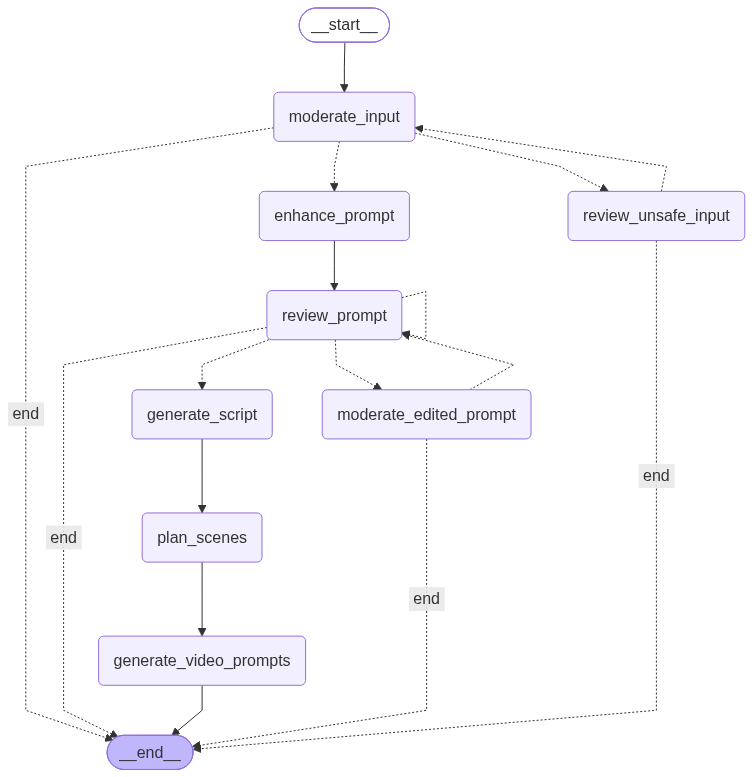

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 9.4 Test Approve Path


In [28]:
initial_state: VideoState = {"user_prompt": ("Create a futuristic 1-minute video explaining "
                                             "AI agents to beginners."
                                             ),
                             "required_words": ["Agentic AI"],
                             "reference_image": None,
                             "moderation_retry_count": 0
                             }

config = {"configurable": {"thread_id": "test-approve-001"}}

response = graph.invoke(initial_state, config = config)

In [29]:
# Inspect the interrupt
pprint(response["__interrupt__"][0].value)

{'enhanced_prompt': {'audience': 'General audience / beginners with little or '
                                 'no technical background who are curious '
                                 'about AI and automation.',
                     'duration_seconds': 60,
                     'key_message': 'Agentic AI are AI systems that act '
                                    'autonomously to plan and carry out '
                                    'multi-step tasks on behalf of people. '
                                    'Unlike traditional AIs that only give '
                                    'answers or predictions, Agentic AI can '
                                    'decide next steps, execute actions, and '
                                    'adapt as things change — making many '
                                    'everyday workflows faster but also '
                                    'requiring human oversight and safety '
                                    'safeguards.',
  

In [30]:
# Approve it
response = graph.invoke(Command(resume = {"action": "approve"}), config = config)

Deserializing unregistered type __main__.EnhancedPrompt from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'EnhancedPrompt')]


In [31]:
print("=== SCRIPT ===")
pprint(response["script"].model_dump())

print("\n=== SCENES ===")
for scene in response["scenes"]:
    pprint(scene.model_dump())

print("\n=== VIDEO PROMPTS ===")
for video_prompt in response["video_prompts"]:
    pprint(video_prompt.model_dump())

=== SCRIPT ===
{'narration': 'Agentic AI are AI systems that act autonomously to plan and '
              'carry out multi-step tasks on behalf of people. Think of them '
              'as assistants that can set goals, make decisions about next '
              'steps, and take actions—rather than just giving a single '
              'answer.\n'
              '\n'
              'Unlike traditional AI tools that only predict or provide '
              'suggestions, Agentic AI can execute sequences: scheduling '
              'meetings across calendars, sending invites and rescheduling '
              'conflicts, triaging and drafting email replies, or coordinating '
              'a delivery robot to pick up and drop off packages and update '
              'you as things change.\n'
              '\n'
              'The benefits are real: less busywork, faster workflows, and '
              'smarter handling of complex tasks. But they also need safety '
              'and oversight—clear